In [1]:
import os

if not os.path.exists('thinkdsp.py'):
    !wget https://github.com/AllenDowney/ThinkDSP/raw/master/code/thinkdsp.py
    !wget https://github.com/AllenDowney/ThinkDSP/raw/master/code/thinkplot.py

import thinkdsp
import thinkplot

--2026-05-19 19:16:46--  https://github.com/AllenDowney/ThinkDSP/raw/master/code/thinkdsp.py
Resolving github.com (github.com)... 140.82.112.3
Connecting to github.com (github.com)|140.82.112.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/AllenDowney/ThinkDSP/master/code/thinkdsp.py [following]
--2026-05-19 19:16:46--  https://raw.githubusercontent.com/AllenDowney/ThinkDSP/master/code/thinkdsp.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 48554 (47K) [text/plain]
Saving to: ‘thinkdsp.py’

thinkdsp.py         100%[===================>]  47.42K  --.-KB/s    in 0.01s   

2026-05-19 19:16:46 (4.13 MB/s) - ‘thinkdsp.py’ saved [48554/48554]

--2026-05-19 19:16:46--  https://github.com/AllenDo

# 5.1

In [2]:
if not os.path.exists('28042__bcjordan__voicedownbew.wav'):
    !wget https://github.com/AllenDowney/ThinkDSP/raw/master/code/28042__bcjordan__voicedownbew.wav

--2026-05-19 20:02:42--  https://github.com/AllenDowney/ThinkDSP/raw/master/code/28042__bcjordan__voicedownbew.wav
Resolving github.com (github.com)... 140.82.112.3
Connecting to github.com (github.com)|140.82.112.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/AllenDowney/ThinkDSP/master/code/28042__bcjordan__voicedownbew.wav [following]
--2026-05-19 20:02:42--  https://raw.githubusercontent.com/AllenDowney/ThinkDSP/master/code/28042__bcjordan__voicedownbew.wav
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.108.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 125996 (123K) [audio/wav]
Saving to: ‘28042__bcjordan__voicedownbew.wav’

28042__bcjordan__vo 100%[===================>] 123.04K  --.-KB/s    in 0.02s   

2026-05-19 20:02:42 (5.68 MB/s)

t=0.20 с, частота=436.6 Гц, корреляция=0.759
t=0.30 с, частота=404.6 Гц, корреляция=0.751
t=0.40 с, частота=380.2 Гц, корреляция=0.743
t=0.50 с, частота=364.5 Гц, корреляция=0.715
t=0.60 с, частота=352.8 Гц, корреляция=0.718
t=0.70 с, частота=347.2 Гц, корреляция=0.711
t=0.80 с, частота=336.6 Гц, корреляция=0.704
t=0.90 с, частота=331.6 Гц, корреляция=0.703
t=1.00 с, частота=331.6 Гц, корреляция=0.686
t=1.10 с, частота=317.3 Гц, корреляция=0.657
t=1.20 с, частота=308.4 Гц, корреляция=0.670


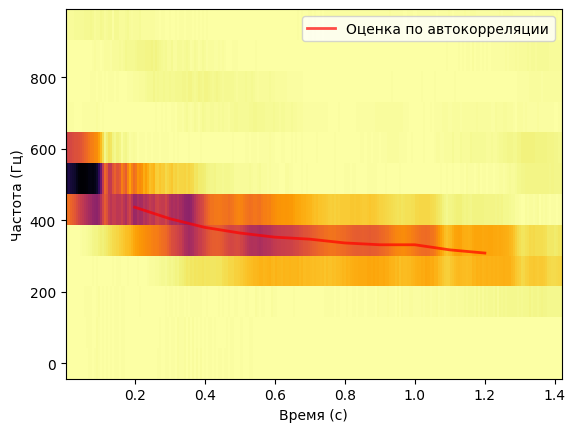

<Figure size 800x600 with 0 Axes>

In [19]:
import numpy as np

def estimate_fundamental(wave, start_time, duration=0.01, framerate=None):
    if framerate is None:
        framerate = wave.framerate
    segment = wave.segment(start=start_time, duration=duration)
    N = len(segment.ys)
    corrs = np.correlate(segment.ys, segment.ys, mode='same')
    half = corrs[N//2:] / corrs[N//2]   # нормализация

    peaks = []
    for lag in range(2, len(half)-1):   # <- исправлено: до len(half)-1
        if half[lag] > half[lag-1] and half[lag] > half[lag+1]:
            peaks.append((lag, half[lag]))
    if not peaks:
        return 0, 0
    best_lag, best_corr = max(peaks, key=lambda x: x[1])
    period = best_lag / framerate
    freq = 1 / period
    return freq, best_corr

# Загружаем запись вокального чирпа
wave = thinkdsp.read_wave('28042__bcjordan__voicedownbew.wav')
# Исследуем частоту в разные моменты времени
start_times = np.linspace(0.2, 1.2, 11)  # 11 точек от 0.2 до 1.2 с
freqs = []
for t in start_times:
    f, c = estimate_fundamental(wave, t, duration=0.01)
    freqs.append(f)
    print(f"t={t:.2f} с, частота={f:.1f} Гц, корреляция={c:.3f}")

spectrogram = wave.make_spectrogram(seg_length=512)
spectrogram.plot(high=1000)
thinkplot.plot(start_times, freqs, color='red', linewidth=2, label='Оценка по автокорреляции')
thinkplot.config(xlabel='Время (с)', ylabel='Частота (Гц)')
thinkplot.show()

Автокорреляция дала правильную и более точную оценку

# 5.2

/content/thinkplot.py:242: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "ro-" (-> color='r'). The keyword argument will take precedence.
  plt.plot(xs, ys, style, **options)


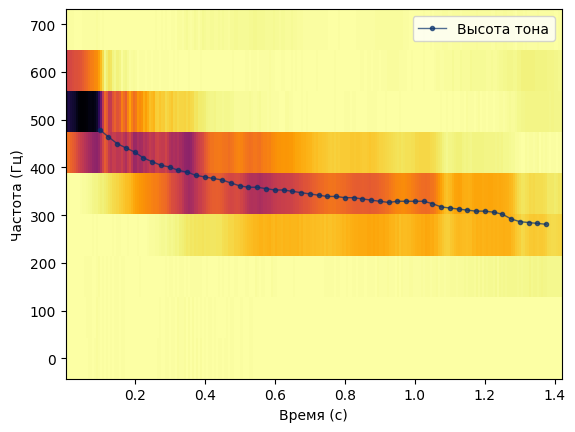

<Figure size 800x600 with 0 Axes>

In [21]:
# напишем новую функцию на основе старой
def estimate_fundamental_robust(wave, start_time, duration=0.02, min_freq=80, max_freq=1000):
    """
    Более надёжная оценка основной частоты.
    Параметры: wave, start_time, duration (с), min_freq, max_freq (Гц).
    Возвращает оценённую частоту или 0, если пик не найден.
    """
    segment = wave.segment(start=start_time, duration=duration)
    framerate = wave.framerate
    N = len(segment.ys)
    # Вычисляем автокорреляцию
    corrs = np.correlate(segment.ys, segment.ys, mode='same')
    half = corrs[N//2:] / corrs[N//2]   # нормализация
    lags = np.arange(len(half)) / framerate
    # Ограничиваем диапазон лагов по частоте
    max_lag = int(1 / min_freq * framerate)
    min_lag = int(1 / max_freq * framerate)
    if min_lag < 2:
        min_lag = 2
    if max_lag > len(half):
        max_lag = len(half) - 1
    # Ищем максимум в заданном интервале
    search_region = half[min_lag:max_lag]
    if len(search_region) == 0:
        return 0
    best_idx = np.argmax(search_region)
    best_lag = min_lag + best_idx
    best_corr = search_region[best_idx]
    # Проверяем, что корреляция достаточно высока (например > 0.5)
    if best_corr < 0.5:
        return 0
    freq = 1 / (best_lag / framerate)
    return freq

# Применяем ко всей записи
wave = thinkdsp.read_wave('28042__bcjordan__voicedownbew.wav')
wave = wave.segment(start=0, duration=1.5)   # первые 1.5 секунды
start_times = np.arange(0.1, 1.4, 0.025)
pitches = []
for t in start_times:
    f = estimate_fundamental_robust(wave, t, duration=0.03)
    pitches.append(f)
# Строим спектрограмму и накладываем оценки
spectrogram = wave.make_spectrogram(seg_length=512)
spectrogram.plot(high=800)
thinkplot.plot(start_times, pitches, 'ro-', markersize=3, linewidth=1, label='Высота тона')
thinkplot.config(xlabel='Время (с)', ylabel='Частота (Гц)')
thinkplot.show()

# 5.3

In [24]:
if not os.path.exists('BTC_USD_2013-10-01_2020-03-26-CoinDesk.csv'):
    !wget https://github.com/AllenDowney/ThinkDSP/raw/master/code/BTC_USD_2013-10-01_2020-03-26-CoinDesk.csv

--2026-05-19 20:17:35--  https://github.com/AllenDowney/ThinkDSP/raw/master/code/BTC_USD_2013-10-01_2020-03-26-CoinDesk.csv
Resolving github.com (github.com)... 140.82.112.4
Connecting to github.com (github.com)|140.82.112.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/AllenDowney/ThinkDSP/master/code/BTC_USD_2013-10-01_2020-03-26-CoinDesk.csv [following]
--2026-05-19 20:17:35--  https://raw.githubusercontent.com/AllenDowney/ThinkDSP/master/code/BTC_USD_2013-10-01_2020-03-26-CoinDesk.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.111.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 143622 (140K) [text/plain]
Saving to: ‘BTC_USD_2013-10-01_2020-03-26-CoinDesk.csv’

BTC_USD_2013-10-01_ 100%[===================>] 140.26K  --.-KB/s    in 0.02

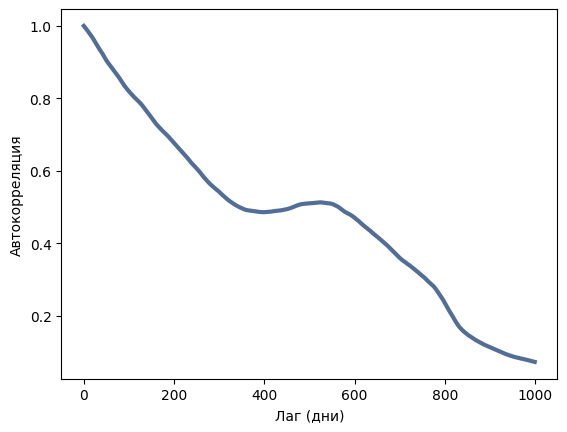

<Figure size 800x600 with 0 Axes>

In [31]:
import pandas as pd
import numpy as np

def autocorr(wave):
    """Возвращает (lags, corrs) для положительных лагов."""
    N = len(wave.ys)
    corrs = np.correlate(wave.ys, wave.ys, mode='same')
    # Нормализуем, чтобы при lag=0 было 1
    corrs = corrs / corrs[N//2]
    lags = np.arange(0, N//2)
    return lags, corrs[N//2:]

df = pd.read_csv('BTC_USD_2013-10-01_2020-03-26-CoinDesk.csv',
                 parse_dates=[0])

prices = df['Closing Price (USD)'].values[::-1]  # в хронологическом порядке
ts = df.index

# Создаём Wave с частотой кадров 1 (отсчёт в день)
wave = thinkdsp.Wave(prices, ts, framerate=1)

# Автокорреляция
lags, corrs = autocorr(wave)
# Нормализуем, чтобы при lag=0 было 1
corrs = corrs / corrs[0]
thinkplot.plot(lags[:1000], corrs[:1000])
thinkplot.config(xlabel='Лаг (дни)', ylabel='Автокорреляция')
thinkplot.show()

Спадает медленно, признаков периодичности нет

# 5.4

In [32]:
if not os.path.exists('28042__bcjordan__voicedownbew.wav'):
    !wget https://github.com/AllenDowney/ThinkDSP/raw/master/code/28042__bcjordan__voicedownbew.wav

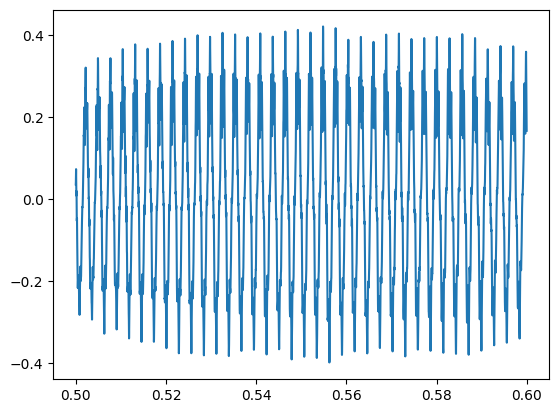

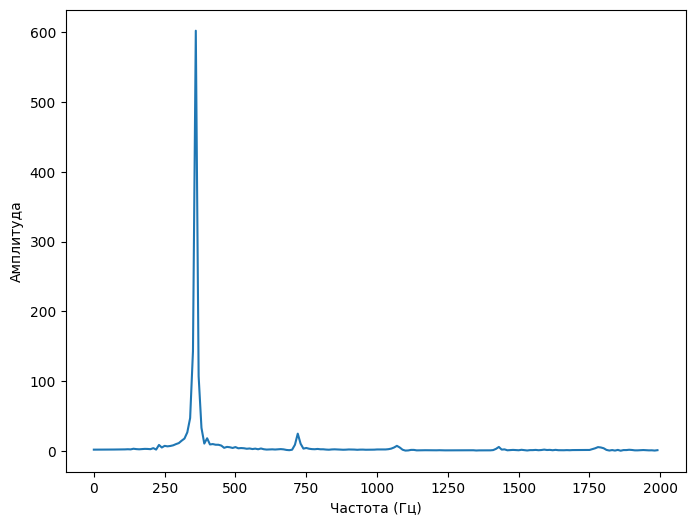

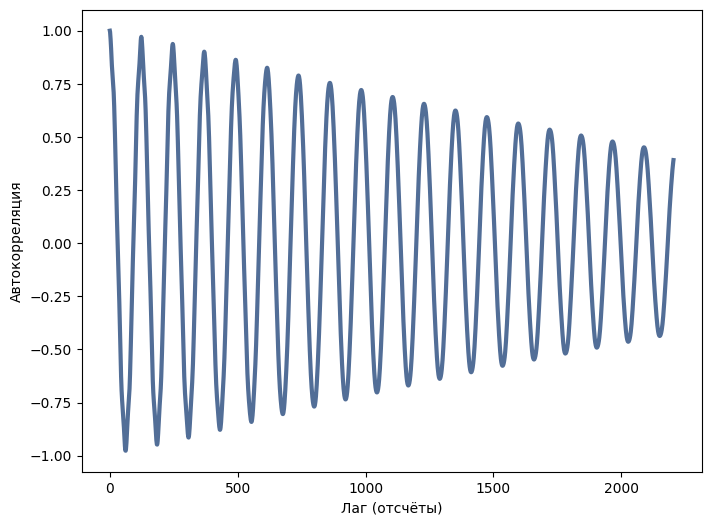

Основная частота по автокорреляции: 39.9 Гц


<Figure size 800x600 with 0 Axes>

In [34]:
import numpy as np

# Загрузка записи саксофона (файл из репозитория)
wave = thinkdsp.read_wave('28042__bcjordan__voicedownbew.wav')
# Выберем другой сегмент, например, 0.5–0.6 секунды (нота без атаки)
segment = wave.segment(start=0.5, duration=0.1)
segment.plot()
thinkplot.show()

# Спектр сегмента
spectrum = segment.make_spectrum()
spectrum.plot(high=2000)
thinkplot.config(xlabel='Частота (Гц)', ylabel='Амплитуда')
thinkplot.show()

# Автокорреляция для оценки периода
lags, corrs = autocorr(segment)
thinkplot.plot(lags, corrs)
thinkplot.config(xlabel='Лаг (отсчёты)', ylabel='Автокорреляция')
thinkplot.show()

# Поиск пика, соответствующего периоду
framerate = wave.framerate
half = len(corrs)//2
peak_lag = np.argmax(corrs[half:half+200]) + half
period = peak_lag / framerate
freq = 1 / period
print(f"Основная частота по автокорреляции: {freq:.1f} Гц")

# Проверим, есть ли пик на этой частоте в спектре
# Если основная частота подавлена, её амплитуда будет мала,
# но автокорреляция всё равно её обнаружит.

 Подавленная основная – ситуация, когда в спектре сигнала отсутствует или очень слаба компонента на основной частоте, но слух всё равно воспринимает эту высоту тона благодаря гармоникам.